# Line Delay Rankings

Ranks lines separately by late-only and early-only delay.

In [1]:
from pathlib import Path
import importlib.util
import sys

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT / "analysis"))

spec = importlib.util.spec_from_file_location(
    "line_delay_rankings",
    PROJECT_ROOT / "analysis" / "line-delay-rankings.py",
)
rankings = importlib.util.module_from_spec(spec)
spec.loader.exec_module(rankings)

DB = PROJECT_ROOT / "data" / "foli.db"
MIN_OBSERVATIONS = 50
LIMIT = 10

In [2]:
class Args:
    db = DB

df = rankings.load_observations(Args)
late = rankings.rank_late(df, MIN_OBSERVATIONS, LIMIT)
early = rankings.rank_early(df, MIN_OBSERVATIONS, LIMIT)
late

,line_ref,line_name,late_obs_count,avg_late_min,median_late_min,max_late_min
119,N6,N6,495,65.62,55.60,179.92
101,L13,L13,296,52.71,50.79,124.97
88,901,901,3955,34.83,9.62,208.53
97,L1,L1,225,29.34,24.45,80.82
72,721,721,683,17.71,5.50,98.35
55,67,67,397,16.79,10.42,60.30
108,L7,L7,186,12.83,2.65,47.97
51,612,612,490,8.59,7.30,19.53
99,L11,L11,650,8.52,4.13,44.42
52,614,614,918,8.15,5.98,40.30


In [3]:
early

,line_ref,line_name,early_obs_count,avg_early_min,median_early_min,max_early_min
111,N11,N11,714,111.68,14.73,263.92
87,901,901,3630,28.75,7.37,183.63
78,77,77,412,23.83,5.98,265.30
77,76,76,333,19.12,3.57,62.57
132,V3,V3,283,16.10,12.28,48.85
80,79,79,367,10.21,1.38,62.87
127,P6,P6,799,9.70,6.23,67.15
34,42,42,161,9.21,1.12,36.83
75,74,74,252,7.71,1.63,60.52
53,615,615,425,6.23,5.50,16.17


Text(0, 0.5, 'Line')

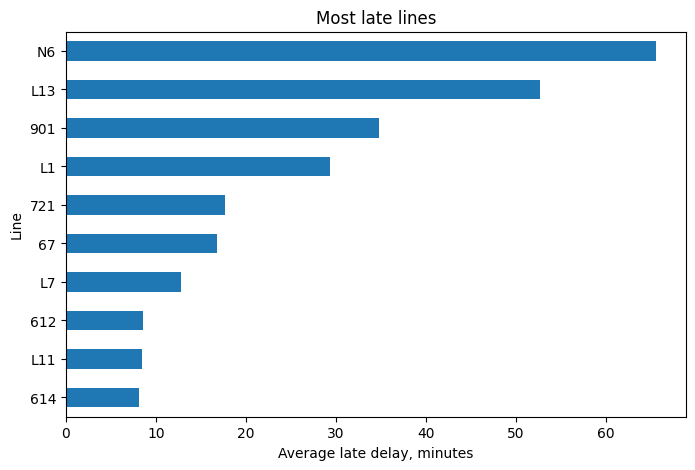

In [4]:
ax = late.sort_values("avg_late_min").plot.barh(
    x="line_ref",
    y="avg_late_min",
    legend=False,
    figsize=(8, 5),
    title="Most late lines",
)
ax.set_xlabel("Average late delay, minutes")
ax.set_ylabel("Line")